In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [ ]:
#download latest version
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df=pd.read_csv(os.path.join(path,"AB_NYC_2019.csv"))
df.head()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.shape

(48895, 16)

In [ ]:
df["room_type"].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

# MISSING VALUE

In [ ]:
 missing=df.isna().sum()
 missing[missing>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


# TARGET VARIABLE-ROOM_TYPE

<Axes: xlabel='room_type', ylabel='count'>

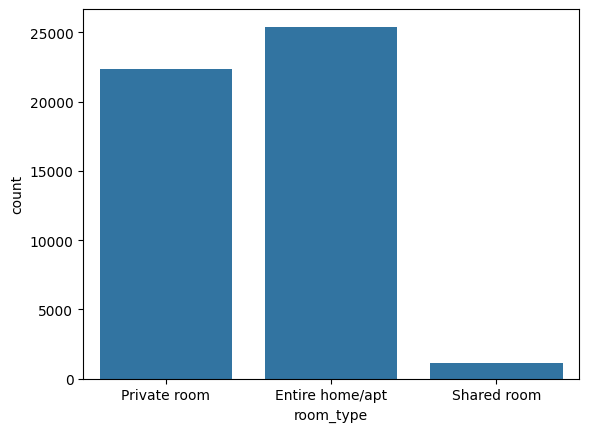

In [ ]:
df["room_type"].value_counts()
sns.countplot(x="room_type",data=df)

the classeses are imbalanced means it create a bias=shared room is a small minority


# UNIVARIATE ANALYSIS-NUMERIC FEATURES

In [ ]:
Numeric_cols=["price","minimum_nights","number_of_reviews","reviews_per_month","calculated_host_listings_count","availability_365"]


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

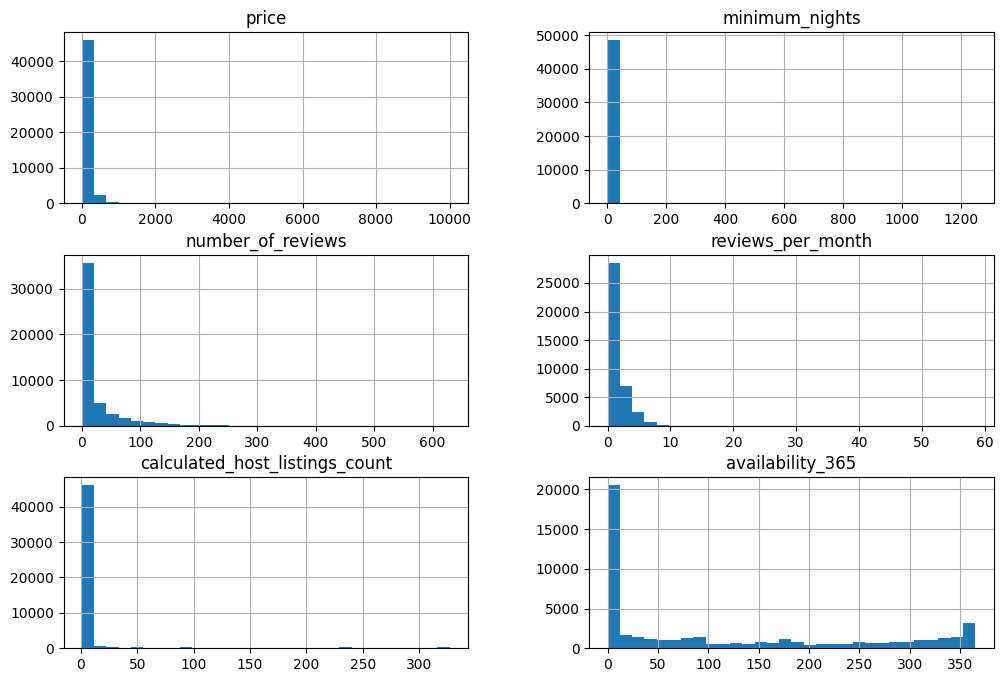

In [ ]:
df[Numeric_cols].hist(bins=30,figsize=(12,8))

#BIVARIATE ANALYSIS-FEATURES VS TARGET


<Axes: xlabel='room_type', ylabel='price'>

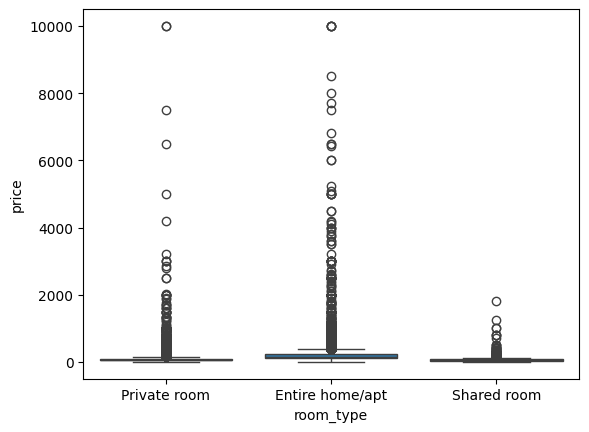

In [ ]:
sns.boxplot(x="room_type",y="price",data=df)

CORRELATION BETWEEN NUMERIC FEATURES

In [ ]:
corr=df[Numeric_cols+['latitude','latitude']].corr()
corr

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,latitude,latitude
price,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829,0.033939,0.033939
minimum_nights,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303,0.024869,0.024869
number_of_reviews,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028,-0.015389,-0.015389
reviews_per_month,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791,-0.010142,-0.010142
calculated_host_listings_count,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701,0.019517,0.019517
availability_365,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000,-0.010983,-0.010983
latitude,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983,1.000000,1.000000
latitude,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983,1.000000,1.000000


<Axes: >

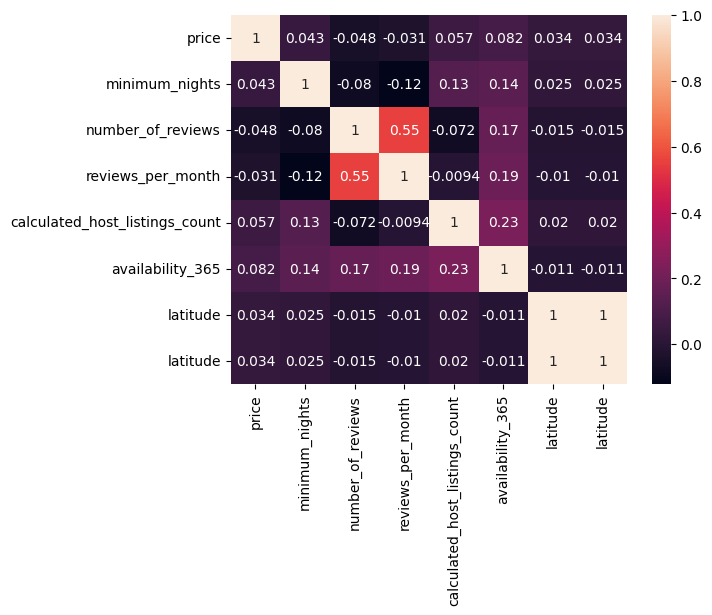

In [ ]:
sns.heatmap(corr,annot=True)

<Axes: xlabel='latitude', ylabel='longitude'>

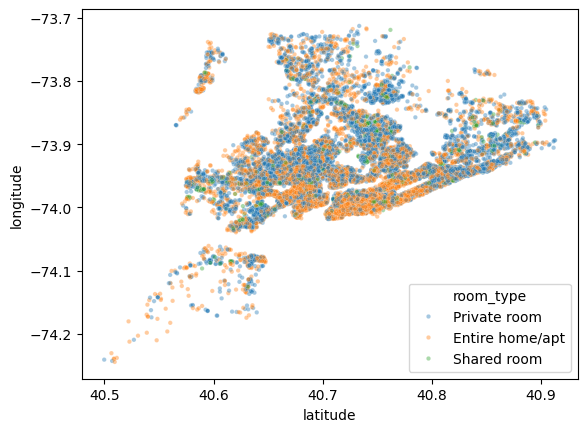

In [ ]:
sns.scatterplot(x="latitude",y="longitude",hue="room_type",data=df,alpha=0.4,s=10)

DATA CLEANING AND FEATURE ENGINEERING

In [ ]:
#DROP COLUMNS THST DONT HELP US
df_clean=df.drop(columns=["id","name","host_id","host_name","last_review"])
#NO reviews yet->0review per month not missing
df_clean["reviews_per_month"]=df_clean["reviews_per_month"].fillna(0,inplace=True)

In [ ]:
#cap extreme outliers instead of deleting rows
price_cap= df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean=df_clean[df_clean['price']<price_cap]
df_clean=df_clean[df_clean['minimum_nights']<nights_cap]

In [ ]:
X=df_clean.drop(columns=["room_type"])
y=df_clean["room_type"]


# TRAIN/TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.33, random_state=42,stratify=y)

# PREPROCESSING:COLUMNTRANSFER + PIPELINE

In [ ]:
df_clean[Numeric_cols].skew()

,0
price,2.234027
minimum_nights,2.29793
number_of_reviews,3.666398
reviews_per_month,NaN
calculated_host_listings_count,7.910731
availability_365,0.780236


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer


# TRYING MULTIPLE MODELS

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Corrected feature lists for the preprocessor
# 'room_type' was the target variable and should not be in the features for ColumnTransformer.
# 'latitude' was duplicated in Numeric_cols.
feature_numeric_cols = ["latitude","longitude","price","minimum_nights","number_of_reviews","reviews_per_month","calculated_host_listings_count","availability_365"]
feature_categorical_cols = ["neighbourhood_group","neighbourhood"] # Removed 'room_type'

# Re-define pipelines for numeric and categorical columns
numeric_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# Re-define preprocessor with corrected feature lists
preprocessor = ColumnTransformer(transformers=[
    ('numerical', numeric_pipeline, feature_numeric_cols),
    ('categorical', categorical_pipeline, feature_categorical_cols)
])


models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="accuracy"
    )

    print(f"{name}: {scores.mean():.3f}")

LogisticRegression: 0.672
DecisionTree: 0.787
RandomForest: 0.853
GradientBoosting: 0.851


# HYPERPARAMETER TUNNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
best_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(class_weight='balanced'))


])

param_distributions={
    "classifier__n_estimators":[100,200,150,300],
    "classifier__max_depth":[8,12,15,20,None],
    "classifier__min_samples_split":[2,5,10],
}

search=RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    random_state=42
)

search.fit(X_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('Scaler',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('cate...
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   n_iter=5,
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Best parameters:",search.best_params_)
print("Best  cv accuracy:",search.best_score_)

Best parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 20}
Best  cv accuracy: 0.8475505310037684


# FINAL EVALUATION ON THE TEST SET

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
best_pipeline=search.best_estimator_
y_pred=best_pipeline.predict(X_test)
print(f"Accuracy Score:{accuracy_score(y_test,y_pred)}")
print(f"F1 Score:{f1_score(y_test,y_pred,average='macro')}")


Accuracy Score:0.849645928174001
F1 Score:0.7402381136918016


<Axes: >

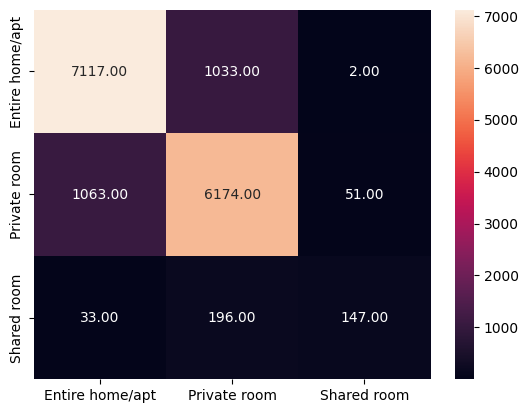

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt=".2f",xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)

In [ ]:
import joblib
joblib.dump(best_pipeline,"Model_Pipeline.pkl")

['Model_Pipeline.pkl']